# Part 2 — Object Detection: Dataset & Model Architectures

**Dataset**: Lettuce Pallets (5 classes, COCO format)  
**Exp 3**: Faster R-CNN ResNet-50 FPN  
**Exp 4**: SSD300 VGG16

In [1]:
import json
import random
from collections import Counter, defaultdict
from pathlib import Path

%matplotlib inline
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torchinfo import summary
from torchvision.models.detection import (
    FasterRCNN_ResNet50_FPN_Weights,
    SSD300_VGG16_Weights,
    fasterrcnn_resnet50_fpn,
    ssd300_vgg16,
)
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.ssd import SSDClassificationHead

In [2]:
STUDENT_ID = 26045171

torch.manual_seed(STUDENT_ID)
random.seed(STUDENT_ID)
np.random.seed(STUDENT_ID)
if torch.cuda.is_available():
    torch.cuda.manual_seed(STUDENT_ID)

DATASET_ROOT = Path("26045171/Object_Detection/coco")
Path("runs").mkdir(exist_ok=True)

CLASS_NAMES = ["__background__", "Ready", "empty_pod", "germination", "pod", "young"]
NUM_CLASSES = len(CLASS_NAMES)  # 6 (index 0 reserved for background)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE} | Classes: {NUM_CLASSES}")

Device: cuda | Classes: 6


## 1. Dataset

In [3]:
splits = [
    ("train", "train_annotations.json"),
    ("valid", "valid_annotations.json"),
    ("test",  "test_annotations.json"),
]

coco_by_split = {}
for split_name, ann_file in splits:
    with open(DATASET_ROOT / split_name / ann_file) as f:
        coco_by_split[split_name] = json.load(f)

print(f"{'Class':<15}" + "".join(f"{'Train':>8}{'Val':>6}{'Test':>6}".split()[:1]) +
      f"  {'Train':>6}  {'Val':>5}  {'Test':>5}")
print("-" * 40)
for cat_id, cat_name in enumerate(CLASS_NAMES[1:], start=1):
    counts = {}
    for split_name, coco in coco_by_split.items():
        counts[split_name] = sum(1 for a in coco["annotations"] if a["category_id"] == cat_id)
    print(f"  {cat_name:<13}  {counts['train']:>6}  {counts['valid']:>5}  {counts['test']:>5}")
print("-" * 40)
for split_name, coco in coco_by_split.items():
    n_imgs = len(coco["images"])
    n_anns = len(coco["annotations"])
    annotated = len({a["image_id"] for a in coco["annotations"]})
    print(f"  {split_name.capitalize():<13}  images={n_imgs}  annotated={annotated}  annotations={n_anns}")

Class          Train   Train    Val   Test
----------------------------------------
  Ready            1415    285    306
  empty_pod        1190    267    133
  germination      4416   1118   1070
  pod              2591    478    525
  young            4205    809    907
----------------------------------------
  Train          images=1057  annotated=1050  annotations=13817
  Valid          images=226  annotated=224  annotations=2957
  Test           images=226  annotated=226  annotations=2941


### Dataset Example Images

For each class, the training image with the most instances of that class is selected.
Bounding boxes are drawn for all annotations in the image.

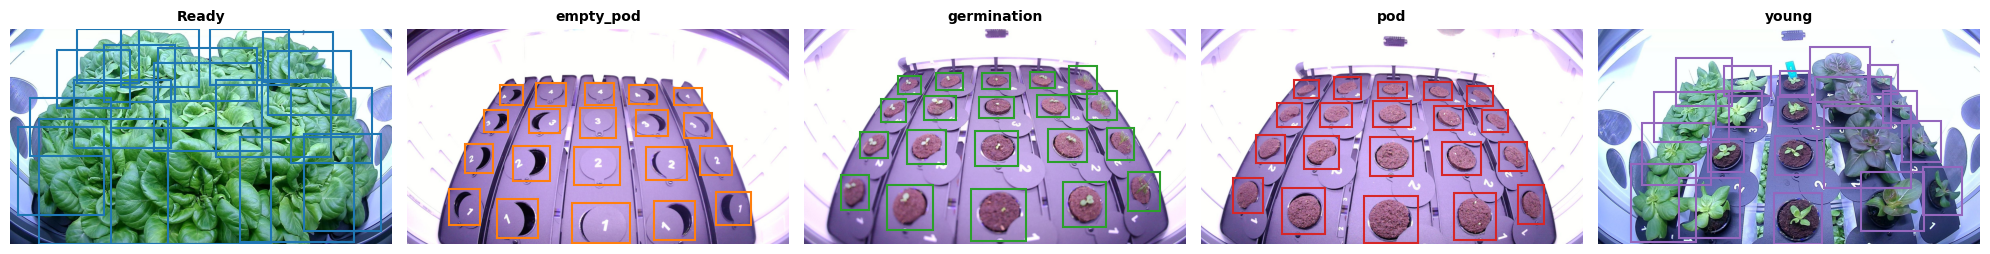

In [4]:
train_coco  = coco_by_split["train"]
img_by_id   = {img["id"]: img for img in train_coco["images"]}
ann_by_img  = defaultdict(list)
ann_by_cat  = defaultdict(list)
for ann in train_coco["annotations"]:
    ann_by_img[ann["image_id"]].append(ann)
    ann_by_cat[ann["category_id"]].append(ann)

# For each class, pick the image with the most instances of that class
representative = {}
for cat_id in range(1, NUM_CLASSES):
    img_counts = Counter(a["image_id"] for a in ann_by_cat[cat_id])
    representative[cat_id] = img_counts.most_common(1)[0][0]

CLASS_COLORS = [
    None,          # background — unused
    "tab:blue",    # Ready
    "tab:orange",  # empty_pod
    "tab:green",   # germination
    "tab:red",     # pod
    "tab:purple",  # young
]

fig, axes = plt.subplots(1, NUM_CLASSES - 1, figsize=(20, 5))
for col, cat_id in enumerate(range(1, NUM_CLASSES)):
    img_id   = representative[cat_id]
    img_meta = img_by_id[img_id]
    img      = Image.open(DATASET_ROOT / "train" / img_meta["file_name"]).convert("RGB")
    anns     = ann_by_img[img_id]

    ax = axes[col]
    ax.imshow(img)
    ax.axis("off")

    for ann in anns:
        x, y, w, h = ann["bbox"]
        cls         = ann["category_id"]
        ax.add_patch(patches.Rectangle(
            (x, y), w, h,
            linewidth=1.5, edgecolor=CLASS_COLORS[cls], facecolor="none"
        ))

    ax.set_title(f"{CLASS_NAMES[cat_id]}", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.savefig("runs/det_dataset_samples.png", dpi=150)
plt.show()

## 2. Model Architectures

### 2.1 Exp 3 — Faster R-CNN (ResNet-50 FPN)

Pretrained on COCO 2017. The `box_predictor` head is replaced with `FastRCNNPredictor(1024, 6)`
to match our 6-class output (background + 5 lettuce classes). All other weights are fine-tuned.

In [5]:
def build_faster_rcnn(num_classes):
    weights = FasterRCNN_ResNet50_FPN_Weights.DEFAULT
    model   = fasterrcnn_resnet50_fpn(weights=weights)
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    return model

frcnn_model = build_faster_rcnn(NUM_CLASSES).to(DEVICE)

total     = sum(p.numel() for p in frcnn_model.parameters())
trainable = sum(p.numel() for p in frcnn_model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}")

Total params:     41,319,661
Trainable params: 41,097,261


In [6]:
frcnn_model.eval()
summary(
    frcnn_model,
    input_size=(1, 3, 500, 500),
)

Layer (type:depth-idx)                                  Output Shape              Param #
FasterRCNN                                              [100, 4]                  --
├─GeneralizedRCNNTransform: 1-1                         [1, 3, 800, 800]          --
├─BackboneWithFPN: 1-2                                  [1, 256, 13, 13]          --
│    └─IntermediateLayerGetter: 2-1                     [1, 2048, 25, 25]         --
│    │    └─Conv2d: 3-1                                 [1, 64, 400, 400]         (9,408)
│    │    └─FrozenBatchNorm2d: 3-2                      [1, 64, 400, 400]         --
│    │    └─ReLU: 3-3                                   [1, 64, 400, 400]         --
│    │    └─MaxPool2d: 3-4                              [1, 64, 200, 200]         --
│    │    └─Sequential: 3-5                             [1, 256, 200, 200]        (212,992)
│    │    └─Sequential: 3-6                             [1, 512, 100, 100]        1,212,416
│    │    └─Sequential: 3-7              

### 2.2 Exp 4 — SSD300 (VGG16)

Pretrained on COCO 2017. The `classification_head` is replaced with `SSDClassificationHead`
configured for 6 classes. The backbone and box regression head keep their pretrained weights.

In [7]:
def build_ssd(num_classes):
    weights = SSD300_VGG16_Weights.DEFAULT
    model   = ssd300_vgg16(weights=weights)
    in_channels = [c.in_channels for c in model.head.classification_head.module_list]
    num_anchors = model.anchor_generator.num_anchors_per_location()
    model.head.classification_head = SSDClassificationHead(
        in_channels, num_anchors, num_classes
    )
    return model

ssd_model = build_ssd(NUM_CLASSES).to(DEVICE)

total     = sum(p.numel() for p in ssd_model.parameters())
trainable = sum(p.numel() for p in ssd_model.parameters() if p.requires_grad)
print(f"Total params:     {total:,}")
print(f"Trainable params: {trainable:,}")

Total params:     24,280,556
Trainable params: 24,241,836


In [8]:
ssd_model.eval()
summary(
    ssd_model,
    input_size=(1, 3, 500, 500),
)

Layer (type:depth-idx)                   Output Shape              Param #
SSD                                      [200, 4]                  --
├─GeneralizedRCNNTransform: 1-1          [1, 3, 300, 300]          --
├─SSDFeatureExtractorVGG: 1-2            [1, 256, 1, 1]            512
│    └─Sequential: 2-1                   [1, 512, 38, 38]          --
│    │    └─Conv2d: 3-1                  [1, 64, 300, 300]         (1,792)
│    │    └─ReLU: 3-2                    [1, 64, 300, 300]         --
│    │    └─Conv2d: 3-3                  [1, 64, 300, 300]         (36,928)
│    │    └─ReLU: 3-4                    [1, 64, 300, 300]         --
│    │    └─MaxPool2d: 3-5               [1, 64, 150, 150]         --
│    │    └─Conv2d: 3-6                  [1, 128, 150, 150]        73,856
│    │    └─ReLU: 3-7                    [1, 128, 150, 150]        --
│    │    └─Conv2d: 3-8                  [1, 128, 150, 150]        147,584
│    │    └─ReLU: 3-9                    [1, 128, 150, 150]     